# EfficientNetV2-M para clasificación de riesgo de glaucoma — Chákṣu

Este notebook implementa el segundo experimento de Transfer Learning y Fine-Tuning para la clasificación binaria de riesgo de glaucoma utilizando EfficientNetV2-M.

Clases funcionales del proyecto:

- 0 = LOW_RISK
- 1 = HIGH_RISK

Correspondencia con las etiquetas originales de Chákṣu:

- NORMAL → LOW_RISK
- GLAUCOMA SUSPECT → HIGH_RISK

El experimento reutiliza las mismas particiones congeladas, preprocesamiento geométrico (detección y recorte de FOV, padding cuadrado, resize a 384 × 384), política de Data Augmentation y ponderación de clases de los experimentos previos.

A diferencia de ResNet50V2, EfficientNetV2-M se configura con `include_preprocessing=True`, por lo que el escalamiento de píxeles forma parte de la propia arquitectura y no se aplica una normalización externa manual a `[-1, 1]`.

Etapas:

1. Verificación del entorno de ejecución y GPU.
2. Configuración general y rutas.
3. Carga y verificación de particiones congeladas.
4. Reutilización del pipeline geométrico y Data Augmentation.
5. Preprocesamiento específico de EfficientNetV2-M.
6. Crear datasets para EfficientNetV2-M.
7. Verificar entrada de EfficientNetV2-M.
8. Construcción de EfficientNetV2-M.
9. Verificación de arquitectura.
10. Forward pass en GPU.
13. Inspección de la etapa final de EfficientNetV2-M.
14. Fase 2 — Fine-Tuning.
15. Configuración del Fine-Tuning.
16. Prueba de memoria antes de entrenar.
17. Callbacks de Fine-Tuning.
18. Entrenamiento de Fine-Tuning.
19. Consolidación de historiales de entrenamiento.
20. Curvas de entrenamiento.
21. Comparación entre Transfer Learning y Fine-Tuning.


## 1. Verificación del entorno y GPU

Comprobación de las versiones de Python y TensorFlow, detección de dispositivos de aceleración por hardware (GPU) y configuración de crecimiento dinámico de memoria VRAM (`set_memory_growth`) para evitar la reserva total inmediata de la memoria gráfica.

In [1]:
from pathlib import Path
import sys
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU disponibles:", gpus)

if not gpus:
    raise RuntimeError(
        "No se detectó ninguna GPU. "
        "No continuar con el entrenamiento."
    )

for gpu in gpus:
    tf.config.experimental.set_memory_growth(
        gpu,
        True
    )


I0000 00:00:1790712919.763896  106546 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790712919.983334  106546 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790712921.759446  106546 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Python: 3.12.14 (main, Sep 24 2026, 17:57:43) [Clang 22.1.3 ]
TensorFlow: 2.21.0
GPU disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1790712923.795795  106546 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 2. Configuración general y rutas

Definición de las rutas del proyecto en el entorno Linux/WSL, directorios de salida para pesos del modelo (`models/glaucoma/efficientnetv2m`) y métricas experimentales (`results/glaucoma/efficientnetv2m`), fijación de semilla común (`RANDOM_STATE = 42`) y parámetros de resolución y tamaño de lote (`IMAGE_SIZE = 384`, `BATCH_SIZE = 8`).


In [2]:
PROJECT_ROOT = Path(
    "/mnt/c/Users/SeuNg720/Documents/TP1-RetiScan"
)
CHAKSU_ROOT = (
    PROJECT_ROOT
    / "datasets"
    / "glaucoma"
    / "chaksu"
)
METADATA_DIR = CHAKSU_ROOT / "metadata"
SPLITS_PATH = (
    METADATA_DIR
    / "chaksu_splits.csv"
)
MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "glaucoma"
    / "efficientnetv2m"
)
RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "glaucoma"
    / "efficientnetv2m"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

IMAGE_SIZE = 384
BATCH_SIZE = 8
RANDOM_STATE = 42

NUM_PARALLEL_CALLS = 2
PREFETCH_BUFFER = 1

tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Proyecto:", PROJECT_ROOT)
print("Splits:", SPLITS_PATH)
print("Modelos:", MODEL_DIR)
print("Resultados:", RESULTS_DIR)
print(
    "\nExiste chaksu_splits.csv:",
    SPLITS_PATH.exists()
)

Proyecto: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan
Splits: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/datasets/glaucoma/chaksu/metadata/chaksu_splits.csv
Modelos: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/glaucoma/efficientnetv2m
Resultados: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/results/glaucoma/efficientnetv2m

Existe chaksu_splits.csv: True


## 3. Carga y verificación de particiones congeladas

Lectura del archivo maestro de particiones `chaksu_splits.csv` y validación estricta de integridad (conteo de muestras y balance de clases exacto por partición) para verificar la integridad de las particiones y favorecer la reproducibilidad experimental, impidiendo cualquier fuga o desalineación de datos.

In [3]:
df = pd.read_csv(
    SPLITS_PATH
)
train_df = df[
    df["experimental_split"] == "train"
].copy()
val_df = df[
    df["experimental_split"] == "validation"
].copy()
test_df = df[
    df["experimental_split"] == "test"
].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

assert len(train_df) == 807
assert len(val_df) == 202
assert len(test_df) == 336
assert train_df["label"].value_counts().to_dict() == {
    0: 697,
    1: 110
}
assert val_df["label"].value_counts().to_dict() == {
    0: 175,
    1: 27
}
assert test_df["label"].value_counts().to_dict() == {
    0: 285,
    1: 51
}
print("Splits congelados verificados correctamente.")


Train: 807
Validation: 202
Test: 336
Splits congelados verificados correctamente.


## 4. Reutilización del pipeline geométrico y Data Augmentation

Incorporación idéntica del pipeline geométrico previamente validado (detección de FOV por contorno convexo, recorte con margen, padding cuadrado y redimensionamiento a 384 × 384), la capa de Data Augmentation conservadora para Train (flip horizontal, rotación de ±11°, zoom isotrópico de ±10% y contraste de ±10%) y el cálculo de pesos balanceados de clase exclusivamente a partir de Train.

In [4]:
def resolver_ruta(ruta_relativa):
    return PROJECT_ROOT / Path(ruta_relativa)

def detectar_fov(imagen_rgb, umbral=10):
    gris = cv2.cvtColor(
        imagen_rgb,
        cv2.COLOR_RGB2GRAY
    )
    _, mascara_inicial = cv2.threshold(
        gris,
        umbral,
        255,
        cv2.THRESH_BINARY
    )
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (15, 15)
    )
    mascara_limpia = cv2.morphologyEx(
        mascara_inicial,
        cv2.MORPH_CLOSE,
        kernel
    )
    num_labels, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            mascara_limpia,
            connectivity=8
        )
    )
    if num_labels <= 1:
        return None, None
    areas = stats[
        1:,
        cv2.CC_STAT_AREA
    ]
    mayor_componente = (
        1 + np.argmax(areas)
    )
    mascara_componente = (
        labels == mayor_componente
    ).astype(np.uint8) * 255
    contornos, _ = cv2.findContours(
        mascara_componente,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )
    if len(contornos) == 0:
        return None, None
    contorno_principal = max(
        contornos,
        key=cv2.contourArea
    )
    hull = cv2.convexHull(
        contorno_principal
    )
    mascara_fov = np.zeros_like(
        mascara_componente
    )
    cv2.fillConvexPoly(
        mascara_fov,
        hull,
        255
    )
    x, y, w, h = cv2.boundingRect(
        hull
    )
    return mascara_fov, (x, y, w, h)

def ampliar_bbox(
    bbox,
    image_width,
    image_height,
    margen=0.02
):
    x, y, w, h = bbox
    margen_x = int(w * margen)
    margen_y = int(h * margen)
    x1 = max(
        0,
        x - margen_x
    )
    y1 = max(
        0,
        y - margen_y
    )
    x2 = min(
        image_width,
        x + w + margen_x
    )
    y2 = min(
        image_height,
        y + h + margen_y
    )
    return x1, y1, x2, y2

def recortar_fov(imagen_rgb):
    mascara, bbox = detectar_fov(
        imagen_rgb
    )
    if bbox is None:
        return imagen_rgb, None
    imagen_enmascarada = cv2.bitwise_and(
        imagen_rgb,
        imagen_rgb,
        mask=mascara
    )
    alto, ancho = imagen_rgb.shape[:2]
    x1, y1, x2, y2 = ampliar_bbox(
        bbox,
        image_width=ancho,
        image_height=alto,
        margen=0.02
    )
    recorte = imagen_enmascarada[
        y1:y2,
        x1:x2
    ]
    return recorte, (
        x1,
        y1,
        x2,
        y2
    )

def padding_cuadrado(imagen_rgb):
    alto, ancho = imagen_rgb.shape[:2]
    lado = max(alto, ancho)
    imagen_cuadrada = np.zeros(
        (lado, lado, 3),
        dtype=imagen_rgb.dtype
    )
    y_offset = (lado - alto) // 2
    x_offset = (lado - ancho) // 2
    imagen_cuadrada[
        y_offset:y_offset + alto,
        x_offset:x_offset + ancho
    ] = imagen_rgb
    return imagen_cuadrada

def redimensionar_imagen(
    imagen_rgb,
    size=IMAGE_SIZE
):
    return cv2.resize(
        imagen_rgb,
        (size, size),
        interpolation=cv2.INTER_AREA
    )

def preprocesar_geometria(
    imagen_rgb,
    size=IMAGE_SIZE
):
    recorte, bbox = recortar_fov(
        imagen_rgb
    )
    if bbox is None:
        raise ValueError(
            "No se pudo detectar el campo de visión retinal."
        )
    imagen_cuadrada = padding_cuadrado(
        recorte
    )
    imagen_resize = redimensionar_imagen(
        imagen_cuadrada,
        size=size
    )
    return imagen_resize, bbox

def cargar_y_preprocesar_python(
    image_path,
    label
):
    ruta = resolver_ruta(
        image_path.decode("utf-8")
    )
    with Image.open(ruta) as img:
        imagen_rgb = np.array(
            img.convert("RGB")
        )
    procesada, _ = preprocesar_geometria(
        imagen_rgb,
        size=IMAGE_SIZE
    )
    procesada = procesada.astype(
        np.float32
    )
    return procesada, np.float32(label)

def cargar_y_preprocesar_tf(
    image_path,
    label
):
    imagen, etiqueta = tf.numpy_function(
        func=cargar_y_preprocesar_python,
        inp=[
            image_path,
            label
        ],
        Tout=[
            tf.float32,
            tf.float32
        ]
    )
    imagen.set_shape(
        [IMAGE_SIZE, IMAGE_SIZE, 3]
    )
    etiqueta.set_shape([])
    return imagen, etiqueta

def crear_dataset_base(
    dataframe,
    shuffle=False
):
    rutas = dataframe[
        "image_path"
    ].astype(str).values
    etiquetas = dataframe[
        "label"
    ].astype(np.float32).values
    ds = tf.data.Dataset.from_tensor_slices(
        (
            rutas,
            etiquetas
        )
    )
    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(dataframe),
            seed=RANDOM_STATE,
            reshuffle_each_iteration=True
        )
    ds = ds.map(
        cargar_y_preprocesar_tf,
        num_parallel_calls=NUM_PARALLEL_CALLS
    )
    return ds

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            "horizontal"
        ),
        tf.keras.layers.RandomRotation(
            factor=0.03,
            fill_mode="constant",
            fill_value=0.0
        ),
        tf.keras.layers.RandomZoom(
            height_factor=(-0.10, 0.10),
            fill_mode="constant",
            fill_value=0.0
        ),
        tf.keras.layers.RandomContrast(
            factor=0.10
        )
    ],
    name="data_augmentation"
)

def aplicar_augmentation(
    imagen,
    etiqueta
):
    imagen = data_augmentation(
        imagen,
        training=True
    )
    return imagen, etiqueta

clases = np.array(
    sorted(
        train_df["label"].unique()
    )
)
pesos = compute_class_weight(
    class_weight="balanced",
    classes=clases,
    y=train_df["label"].values
)
class_weights = {
    int(clase): float(peso)
    for clase, peso in zip(
        clases,
        pesos
    )
}
print(class_weights)

{0: 0.578909612625538, 1: 3.668181818181818}


W0000 00:00:1790712933.080177  106546 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1790712933.431964  106546 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9217 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:01:00.0, compute capability: 12.0a


## 5. Preprocesamiento específico de EfficientNetV2-M

EfficientNetV2-M se instancia con `include_preprocessing=True`, por lo
que el escalamiento requerido por la arquitectura forma parte del propio
modelo.

En consecuencia, las imágenes se entregan al backbone como tensores
`float32` manteniendo el rango original aproximado `[0, 255]`.

No se aplica `preprocess_input` externo para evitar una doble
normalización.


In [5]:
def preprocess_efficientnetv2(
    imagen,
    etiqueta
):
    imagen = tf.cast(
        imagen,
        tf.float32
    )
    return imagen, etiqueta


## 6. Crear datasets para EfficientNetV2-M

Integración del pipeline completo con `tf.data`: Data Augmentation exclusiva para Train, preprocesamiento específico `preprocess_efficientnetv2` (`float32` en escala `[0, 255]`) para todos los subconjuntos, empaquetado en lotes de tamaño 8 (`batch(BATCH_SIZE)`) y precarga controlada con `prefetch(PREFETCH_BUFFER)` para limitar el consumo de memoria.


In [6]:
train_ds = crear_dataset_base(
    train_df,
    shuffle=True
)
val_ds = crear_dataset_base(
    val_df,
    shuffle=False
)
test_ds = crear_dataset_base(
    test_df,
    shuffle=False
)

train_ds = train_ds.map(
    aplicar_augmentation,
    num_parallel_calls=NUM_PARALLEL_CALLS
)
train_ds = train_ds.map(
    preprocess_efficientnetv2,
    num_parallel_calls=NUM_PARALLEL_CALLS
)
val_ds = val_ds.map(
    preprocess_efficientnetv2,
    num_parallel_calls=NUM_PARALLEL_CALLS
)
test_ds = test_ds.map(
    preprocess_efficientnetv2,
    num_parallel_calls=NUM_PARALLEL_CALLS
)

train_ds = (
    train_ds
    .batch(BATCH_SIZE)
    .prefetch(PREFETCH_BUFFER)
)
val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(PREFETCH_BUFFER)
)
test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(PREFETCH_BUFFER)
)


## 7. Verificar entrada de EfficientNetV2-M

Inspección del primer lote generado por `train_ds` para comprobar que las dimensiones espaciales coincidan con `(8, 384, 384, 3)` y que los valores mínimo y máximo de píxeles se ubiquen en el rango aproximado `[0, 255]`, sin normalización externa a `[-1, 1]`.


In [ ]:
for images_batch, labels_batch in train_ds.take(1):
    print(
        "Shape:",
        images_batch.shape
    )
    print(
        "Min:",
        float(tf.reduce_min(images_batch))
    )
    print(
        "Max:",
        float(tf.reduce_max(images_batch))
    )
    print(
        "Labels:",
        labels_batch.numpy()
    )


## 8. Construcción de EfficientNetV2-M

Se utiliza EfficientNetV2-M preentrenada sobre ImageNet como segundo
backbone candidato para la clasificación binaria de riesgo de glaucoma.

Durante la primera fase de Transfer Learning el backbone permanece
completamente congelado.

La cabeza clasificadora mantiene la misma configuración empleada con
ResNet50V2: Global Average Pooling, Dropout de 0.30 y una neurona de
salida sigmoid.


In [ ]:
base_model = tf.keras.applications.EfficientNetV2M(
    include_top=False,
    weights="imagenet",
    input_shape=(
        IMAGE_SIZE,
        IMAGE_SIZE,
        3
    ),
    include_preprocessing=True
)
base_model.trainable = False

inputs = tf.keras.Input(
    shape=(
        IMAGE_SIZE,
        IMAGE_SIZE,
        3
    )
)
x = base_model(
    inputs,
    training=False
)
x = tf.keras.layers.GlobalAveragePooling2D()(
    x
)
x = tf.keras.layers.Dropout(
    0.30
)(
    x
)
outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(
    x
)
model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="EfficientNetV2M_Chaksu"
)
model.summary()


## 9. Verificación de arquitectura

Inspección cuantitativa de los parámetros del modelo para validar que el backbone permanezca completamente congelado (`base_model.trainable = False`) y que únicamente los parámetros de la cabeza clasificadora sean computados como entrenables para la fase de Transfer Learning.


In [ ]:
total_params = model.count_params()
trainable_params = np.sum(
    [
        np.prod(v.shape)
        for v in model.trainable_weights
    ]
)
non_trainable_params = np.sum(
    [
        np.prod(v.shape)
        for v in model.non_trainable_weights
    ]
)

print(
    "Backbone:",
    base_model.name
)
print(
    "Backbone entrenable:",
    base_model.trainable
)
print(
    "Parámetros totales:",
    f"{total_params:,}"
)
print(
    "Entrenables:",
    f"{trainable_params:,}"
)
print(
    "No entrenables:",
    f"{non_trainable_params:,}"
)


## 10. Forward pass en GPU

Pase hacia adelante (*forward pass*) de prueba con un lote de entrenamiento `(8, 384, 384, 3)` para confirmar la correcta asignación de dispositivo en GPU, verificar las dimensiones de salida `(8, 1)` y asegurar la estabilidad de la memoria gráfica antes del inicio del entrenamiento.


In [ ]:
for images_test, labels_test in train_ds.take(1):
    predictions_test = model(
        images_test,
        training=False
    )
    print(
        "Entrada:",
        images_test.shape
    )
    print(
        "Salida:",
        predictions_test.shape
    )
    print(
        "Dispositivo:",
        predictions_test.device
    )
    print(
        "Primeras predicciones:"
    )
    print(
        predictions_test.numpy()[:8].flatten()
    )


## 11. Configuración de Transfer Learning

Primera fase de entrenamiento de EfficientNetV2-M con el backbone
preentrenado sobre ImageNet completamente congelado.

Se entrena exclusivamente la cabeza clasificadora utilizando los mismos
hiperparámetros y criterios aplicados a ResNet50V2 para mantener la
comparabilidad experimental entre arquitecturas.

El conjunto Test permanece completamente aislado.


### 11.1. Hiperparámetros y rutas

Definición de hiperparámetros de la fase inicial (`INITIAL_LR = 1e-3`, `MAX_EPOCHS_TRANSFER = 20`, `EARLY_STOPPING_PATIENCE = 5`) y rutas de persistencia para el checkpoint del mejor modelo y el registro de métricas por época.


In [ ]:
INITIAL_LR = 1e-3
MAX_EPOCHS_TRANSFER = 20
EARLY_STOPPING_PATIENCE = 5

TRANSFER_MODEL_PATH = (
    MODEL_DIR
    / "efficientnetv2m_transfer_best.keras"
)
TRANSFER_LOG_PATH = (
    RESULTS_DIR
    / "efficientnetv2m_transfer_log.csv"
)

print(
    "Learning rate:",
    INITIAL_LR
)
print(
    "Máximo de epochs:",
    MAX_EPOCHS_TRANSFER
)
print(
    "Paciencia Early Stopping:",
    EARLY_STOPPING_PATIENCE
)
print(
    "Checkpoint:",
    TRANSFER_MODEL_PATH
)
print(
    "Backbone entrenable:",
    base_model.trainable
)


### 11.2. Compilar el modelo

Compilación con optimizador Adam (`learning_rate = 1e-3`), función de pérdida `BinaryCrossentropy` y conjunto de métricas para clasificación desbalanceada: Binary Accuracy (umbral 0.5 provisional), ROC-AUC, PR-AUC, Precision y Recall.


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=INITIAL_LR
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy",
            threshold=0.5
        ),
        tf.keras.metrics.AUC(
            name="roc_auc",
            curve="ROC"
        ),
        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        ),
        tf.keras.metrics.Precision(
            name="precision",
            thresholds=0.5
        ),
        tf.keras.metrics.Recall(
            name="recall",
            thresholds=0.5
        )
    ]
)

print(
    "Modelo compilado para Transfer Learning."
)


### 11.3. Callbacks

Configuración de `ModelCheckpoint`, `EarlyStopping`, `ReduceLROnPlateau`, `CSVLogger` y `TerminateOnNaN` basados en la minimización de `val_loss` para evitar el sobreajuste y preservar los mejores pesos.


In [ ]:
callbacks_transfer = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=TRANSFER_MODEL_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(
        filename=TRANSFER_LOG_PATH,
        append=False
    ),
    tf.keras.callbacks.TerminateOnNaN()
]


## 12. Entrenamiento de Transfer Learning

Entrenamiento exclusivo de la cabeza clasificadora mientras el backbone
EfficientNetV2-M permanece congelado.

La ponderación de clases se aplica únicamente sobre Train. Validation
mantiene su distribución natural y no recibe ponderación de clases.

El mejor checkpoint se selecciona exclusivamente mediante la mínima
`val_loss`.


In [ ]:
import time

inicio_transfer = time.perf_counter()

history_transfer = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS_TRANSFER,
    class_weight=class_weights,
    callbacks=callbacks_transfer,
    shuffle=False,
    verbose=1
)

fin_transfer = time.perf_counter()
tiempo_transfer_seg = (
    fin_transfer
    - inicio_transfer
)

print(
    "\nTiempo total Transfer Learning:",
    f"{tiempo_transfer_seg / 60:.2f} minutos"
)


## 13. Inspección de la etapa final de EfficientNetV2-M

Antes del Fine-Tuning se inspeccionan los nombres de las capas finales
del backbone para identificar de forma explícita su último bloque de
características de alto nivel.

Esto permite aplicar un descongelamiento controlado y comparable
conceptualmente con el bloque final `conv5_x` utilizado en ResNet50V2.


In [ ]:
print(
    "Número total de capas del backbone:",
    len(base_model.layers)
)
print(
    "\nÚltimas 80 capas de EfficientNetV2-M:\n"
)
for i, layer in enumerate(
    base_model.layers[-80:],
    start=len(base_model.layers) - 80
):
    print(
        f"{i:03d}",
        layer.name,
        "|",
        layer.__class__.__name__
    )


## 14. Fase 2 — Fine-Tuning

Tras completar la fase inicial de Transfer Learning, se realiza un ajuste
fino controlado de EfficientNetV2-M.

Se recupera el mejor checkpoint obtenido durante Transfer Learning y se
habilita exclusivamente la última etapa semántica del backbone
(`block7`).

Las capas BatchNormalization permanecen congeladas para preservar las
estadísticas preentrenadas de ImageNet.

Esta estrategia es conceptualmente equivalente al desbloqueo de
`conv5_x` aplicado previamente a ResNet50V2.


### 14.1. Recuperar el mejor modelo de Transfer Learning

Carga del mejor checkpoint obtenido en la fase inicial (`TRANSFER_MODEL_PATH`) y verificación de que el backbone convolucional cargue en estado completamente congelado.


In [7]:
TRANSFER_MODEL_PATH = (
    MODEL_DIR
    / "efficientnetv2m_transfer_best.keras"
)

model = tf.keras.models.load_model(
    TRANSFER_MODEL_PATH,
    compile=False
)

base_model = model.get_layer(
    "efficientnetv2-m"
)

print(
    "Modelo recuperado desde:",
    TRANSFER_MODEL_PATH
)

print(
    "Backbone:",
    base_model.name
)

print(
    "Backbone entrenable al cargar:",
    base_model.trainable
)

Modelo recuperado desde: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/glaucoma/efficientnetv2m/efficientnetv2m_transfer_best.keras
Backbone: efficientnetv2-m
Backbone entrenable al cargar: False


### 14.2. Descongelar únicamente block7

Habilitación de entrenamiento exclusivamente para las capas del bloque final `block7`, excluyendo todas las capas `BatchNormalization` para preservar las estadísticas normalizadas preentrenadas.


In [8]:
base_model.trainable = True
for layer in base_model.layers:
    if (
        layer.name.startswith("block7")
        and not isinstance(
            layer,
            tf.keras.layers.BatchNormalization
        )
    ):
        layer.trainable = True
    else:
        layer.trainable = False


### 14.3. Verificación de capas entrenables del backbone

Inspección de las capas habilitadas del backbone para certificar que pertenezcan estrictamente a `block7` y que la cantidad de capas `BatchNormalization` entrenables sea exactamente 0.


In [9]:
trainable_backbone_layers = [
    layer.name
    for layer in base_model.layers
    if layer.trainable
]
trainable_bn_layers = [
    layer.name
    for layer in base_model.layers
    if (
        layer.trainable
        and isinstance(
            layer,
            tf.keras.layers.BatchNormalization
        )
    )
]

print(
    "Capas entrenables del backbone:",
    len(trainable_backbone_layers)
)
print(
    "\nPrimeras capas entrenables:"
)
for name in trainable_backbone_layers[:15]:
    print(name)
print(
    "\nÚltimas capas entrenables:"
)
for name in trainable_backbone_layers[-15:]:
    print(name)
print(
    "\nBatchNormalization entrenables:",
    len(trainable_bn_layers)
)


Capas entrenables del backbone: 58

Primeras capas entrenables:
block7a_expand_conv
block7a_expand_activation
block7a_dwconv2
block7a_activation
block7a_se_squeeze
block7a_se_reshape
block7a_se_reduce
block7a_se_expand
block7a_se_excite
block7a_project_conv
block7b_expand_conv
block7b_expand_activation
block7b_dwconv2
block7b_activation
block7b_se_squeeze

Últimas capas entrenables:
block7d_project_conv
block7d_drop
block7d_add
block7e_expand_conv
block7e_expand_activation
block7e_dwconv2
block7e_activation
block7e_se_squeeze
block7e_se_reshape
block7e_se_reduce
block7e_se_expand
block7e_se_excite
block7e_project_conv
block7e_drop
block7e_add

BatchNormalization entrenables: 0


### 14.4. Conteo de parámetros entrenables para Fine-Tuning

Cuantificación de parámetros entrenables y no entrenables tras descongelar `block7` y mantener el resto del modelo congelado.


In [10]:
trainable_params_ft = np.sum(
    [
        np.prod(v.shape)
        for v in model.trainable_weights
    ]
)
non_trainable_params_ft = np.sum(
    [
        np.prod(v.shape)
        for v in model.non_trainable_weights
    ]
)

print(
    "Parámetros entrenables:",
    f"{trainable_params_ft:,}"
)
print(
    "Parámetros no entrenables:",
    f"{non_trainable_params_ft:,}"
)
print(
    "Parámetros totales:",
    f"{model.count_params():,}"
)


Parámetros entrenables: 17,637,261
Parámetros no entrenables: 35,514,408
Parámetros totales: 53,151,669


## 15. Configuración del Fine-Tuning

Definición de hiperparámetros de ajuste fino con un learning rate significativamente menor (`FINE_TUNE_LR = 1e-5`, `MAX_EPOCHS_FINE_TUNE = 15`, `FINE_TUNE_PATIENCE = 4`) para evitar la degradación de las representaciones visuales preentrenadas.


In [11]:
FINE_TUNE_LR = 1e-5
MAX_EPOCHS_FINE_TUNE = 15
FINE_TUNE_PATIENCE = 4

FINE_TUNE_MODEL_PATH = (
    MODEL_DIR
    / "efficientnetv2m_finetune_best.keras"
)
FINE_TUNE_LOG_PATH = (
    RESULTS_DIR
    / "efficientnetv2m_finetune_log.csv"
)

print(
    "Learning rate Fine-Tuning:",
    FINE_TUNE_LR
)
print(
    "Máximo de epochs Fine-Tuning:",
    MAX_EPOCHS_FINE_TUNE
)
print(
    "Paciencia Early Stopping:",
    FINE_TUNE_PATIENCE
)
print(
    "Checkpoint Fine-Tuning:",
    FINE_TUNE_MODEL_PATH
)


Learning rate Fine-Tuning: 1e-05
Máximo de epochs Fine-Tuning: 15
Paciencia Early Stopping: 4
Checkpoint Fine-Tuning: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/glaucoma/efficientnetv2m/efficientnetv2m_finetune_best.keras


### 15.2. Configuración de micro-batch y acumulación de gradientes

Recompilación obligatoria del modelo con el nuevo learning rate reducido y actualización del grafo computacional para reflejar las variables entrenables de `block7`.


In [12]:
FINE_TUNE_BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 2

print(
    "Batch físico:",
    FINE_TUNE_BATCH_SIZE
)

print(
    "Pasos de acumulación:",
    GRADIENT_ACCUMULATION_STEPS
)

print(
    "Batch efectivo aproximado:",
    FINE_TUNE_BATCH_SIZE
    * GRADIENT_ACCUMULATION_STEPS
)

Batch físico: 4
Pasos de acumulación: 2
Batch efectivo aproximado: 8


### 15.3. Dataset específico para Fine-Tuning

In [13]:
train_ds_ft = crear_dataset_base(
    train_df,
    shuffle=True
)

train_ds_ft = train_ds_ft.map(
    aplicar_augmentation,
    num_parallel_calls=NUM_PARALLEL_CALLS
)

train_ds_ft = train_ds_ft.map(
    preprocess_efficientnetv2,
    num_parallel_calls=NUM_PARALLEL_CALLS
)

train_ds_ft = (
    train_ds_ft
    .batch(FINE_TUNE_BATCH_SIZE)
    .prefetch(PREFETCH_BUFFER)
)

for images_ft, labels_ft in train_ds_ft.take(1):

    print(
        "Shape Fine-Tuning:",
        images_ft.shape
    )

    print(
        "Labels:",
        labels_ft.numpy()
    )

Shape Fine-Tuning: (4, 384, 384, 3)
Labels: [0. 0. 0. 0.]


### 15.4. Recompilación del modelo

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LR,
        gradient_accumulation_steps=(
            GRADIENT_ACCUMULATION_STEPS
        )
    ),

    loss=tf.keras.losses.BinaryCrossentropy(),

    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy",
            threshold=0.5
        ),

        tf.keras.metrics.AUC(
            name="roc_auc",
            curve="ROC"
        ),

        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        ),

        tf.keras.metrics.Precision(
            name="precision",
            thresholds=0.5
        ),

        tf.keras.metrics.Recall(
            name="recall",
            thresholds=0.5
        )
    ]
)

print(
    "Modelo recompilado para Fine-Tuning "
    "con acumulación de gradientes."
)

Modelo recompilado para Fine-Tuning con acumulación de gradientes.


## 16. Prueba de memoria antes de entrenar

Evaluación del pase hacia adelante y cálculo explícito de gradientes (`tf.GradientTape`) sin actualizar pesos, utilizando un micro-batch de 4 imágenes de 384 × 384. La configuración emplea acumulación de gradientes de 2 pasos para mantener un batch efectivo aproximado de 8 durante el Fine-Tuning de `block7`, debido a las restricciones de memoria de la GPU.


In [ ]:
for images_ft, labels_ft in train_ds_ft.take(1):

    with tf.GradientTape() as tape:

        predictions_ft = model(
            images_ft,
            training=True
        )

        loss_ft = (
            tf.keras.losses.binary_crossentropy(
                labels_ft,
                tf.squeeze(
                    predictions_ft,
                    axis=1
                )
            )
        )

        loss_ft = tf.reduce_mean(
            loss_ft
        )

    gradients_ft = tape.gradient(
        loss_ft,
        model.trainable_variables
    )

    valid_gradients = sum(
        gradient is not None
        for gradient in gradients_ft
    )

    print(
        "Entrada:",
        images_ft.shape
    )

    print(
        "Salida:",
        predictions_ft.shape
    )

    print(
        "Loss de prueba:",
        float(loss_ft)
    )

    print(
        "Variables entrenables:",
        len(model.trainable_variables)
    )

    print(
        "Gradientes válidos:",
        valid_gradients
    )

    print(
        "Prueba Fine-Tuning completada."
    )

## 17. Callbacks de Fine-Tuning

Configuración de los mecanismos de control del entrenamiento mediante
checkpoint del mejor modelo según `val_loss`, Early Stopping,
reducción automática del learning rate y registro de métricas por época.


In [15]:
callbacks_finetune = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=FINE_TUNE_MODEL_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=FINE_TUNE_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(
        filename=FINE_TUNE_LOG_PATH,
        append=False
    ),
    tf.keras.callbacks.TerminateOnNaN()
]


## 18. Entrenamiento de Fine-Tuning

Entrenamiento controlado de la etapa final `block7` de EfficientNetV2-M
utilizando un micro-batch físico de 4 imágenes y acumulación de
gradientes de 2 pasos, equivalente aproximadamente a un batch efectivo
de 8.

Se mantienen congeladas las capas BatchNormalization y se utiliza el
conjunto Validation para seleccionar el mejor checkpoint mediante la
mínima `val_loss`.

El conjunto Test permanece completamente aislado.


In [16]:
import time

inicio_finetune = time.perf_counter()

history_finetune = model.fit(
    train_ds_ft,
    validation_data=val_ds,
    epochs=MAX_EPOCHS_FINE_TUNE,
    class_weight=class_weights,
    callbacks=callbacks_finetune,
    shuffle=False,
    verbose=1
)

fin_finetune = time.perf_counter()
tiempo_finetune_seg = (
    fin_finetune
    - inicio_finetune
)

print(
    "\nTiempo total Fine-Tuning:",
    f"{tiempo_finetune_seg / 60:.2f} minutos"
)


Epoch 1/15


I0000 00:00:1790713230.616850  106677 service.cc:153] XLA service 0x731060033260 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790713230.616901  106677 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070, Compute Capability 12.0a (Driver: 13.4.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1790713231.920528  106677 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790713236.557424  106677 cuda_dnn.cc:461] Loaded cuDNN version 92600
E0000 00:00:1790713241.703226  106677 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790713242.380865  106677 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

201/202 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.6903 - loss: 0.6175 - pr_auc: 0.2816 - precision: 0.2445 - recall: 0.6147 - roc_auc: 0.7260

E0000 00:00:1790713313.949361  106675 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790713314.306744  106675 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790713314.730468  106675 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790713316.070510  106675 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790713316.382604  106675 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.6914 - loss: 0.6183 - pr_auc: 0.2826 - precision: 0.2473 - recall: 0.6182 - roc_auc: 0.7274

E0000 00:00:1790713339.590286  106678 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790713341.164087  106678 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790713341.652531  106678 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790713343.036746  106678 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790713343.802175  106678 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000


Epoch 1: val_loss improved from None to 0.69117, saving model to /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/glaucoma/efficientnetv2m/efficientnetv2m_finetune_best.keras

Epoch 1: finished saving model to /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/glaucoma/efficientnetv2m/efficientnetv2m_finetune_best.keras
202/202 ━━━━━━━━━━━━━━━━━━━━ 150s 524ms/step - accuracy: 0.6914 - loss: 0.6183 - pr_auc: 0.2826 - precision: 0.2473 - recall: 0.6182 - roc_auc: 0.7274 - val_accuracy: 0.5891 - val_loss: 0.6912 - val_pr_auc: 0.4327 - val_precision: 0.2407 - val_recall: 0.9630 - val_roc_auc: 0.8099 - learning_rate: 1.0000e-05
Epoch 2/15
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.7274 - loss: 0.5647 - pr_auc: 0.4084 - precision: 0.2885 - recall: 0.6818 - roc_auc: 0.7832
Epoch 2: val_loss improved from 0.69117 to 0.50738, saving model to /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/glaucoma/efficientnetv2m/efficientnetv2m_finetune_best.keras

Epoch 2: finished savi

## 19. Consolidación de historiales de entrenamiento

Carga de los registros persistidos de Transfer Learning y Fine-Tuning
para identificar de forma reproducible el mejor checkpoint de cada fase
según la mínima `val_loss`.

Los resultados se recuperan desde los archivos CSV generados durante
el entrenamiento, evitando depender del estado actual del kernel.


In [17]:
TRANSFER_LOG_PATH = (
    RESULTS_DIR
    / "efficientnetv2m_transfer_log.csv"
)
FINE_TUNE_LOG_PATH = (
    RESULTS_DIR
    / "efficientnetv2m_finetune_log.csv"
)

print(
    "Transfer log existe:",
    TRANSFER_LOG_PATH.exists()
)
print(
    "Fine-Tuning log existe:",
    FINE_TUNE_LOG_PATH.exists()
)

transfer_history_df = pd.read_csv(
    TRANSFER_LOG_PATH
)
finetune_history_df = pd.read_csv(
    FINE_TUNE_LOG_PATH
)

print(
    "\nÉpocas Transfer Learning:",
    len(transfer_history_df)
)
print(
    "Épocas Fine-Tuning:",
    len(finetune_history_df)
)


Transfer log existe: True
Fine-Tuning log existe: True

Épocas Transfer Learning: 8
Épocas Fine-Tuning: 10


### 19.1. Identificación del mejor checkpoint por fase

Localización de la época óptima según la mínima pérdida de validación (`val_loss`) para Transfer Learning y Fine-Tuning, permitiendo contrastar de forma preliminar la capacidad predictiva de cada fase.


In [18]:
best_transfer_idx = (
    transfer_history_df["val_loss"].idxmin()
)
best_finetune_idx = (
    finetune_history_df["val_loss"].idxmin()
)

best_transfer = transfer_history_df.loc[
    best_transfer_idx
]
best_finetune = finetune_history_df.loc[
    best_finetune_idx
]

best_transfer_epoch = (
    int(best_transfer["epoch"]) + 1
)
best_finetune_epoch = (
    int(best_finetune["epoch"]) + 1
)

print(
    "Mejor época Transfer Learning:",
    best_transfer_epoch
)
print(
    "Mejor val_loss Transfer Learning:",
    float(best_transfer["val_loss"])
)
print()
print(
    "Mejor época Fine-Tuning:",
    best_finetune_epoch
)
print(
    "Mejor val_loss Fine-Tuning:",
    float(best_finetune["val_loss"])
)


Mejor época Transfer Learning: 3
Mejor val_loss Transfer Learning: 0.5200042724609375

Mejor época Fine-Tuning: 6
Mejor val_loss Fine-Tuning: 0.3560798168182373


## 20. Curvas de entrenamiento

Visualización de la evolución de `loss`, ROC-AUC y PR-AUC durante las
fases de Transfer Learning y Fine-Tuning.

Las curvas permiten analizar el comportamiento del aprendizaje y la
separación entre entrenamiento y validación antes de realizar la
comparación final entre arquitecturas.


### 20.1. Curva de pérdida (Loss) — Transfer Learning

Evolución de la función de pérdida en Train y Validation para Transfer Learning, indicando la época óptima seleccionada por Early Stopping.


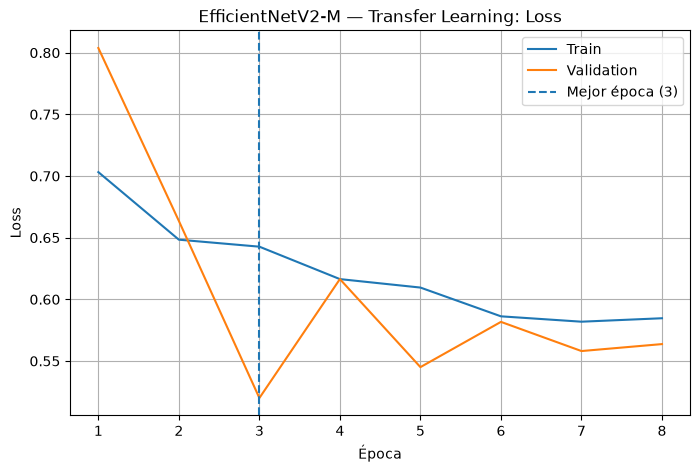

In [19]:
import matplotlib.pyplot as plt

epochs_transfer = (
    transfer_history_df["epoch"] + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_transfer,
    transfer_history_df["loss"],
    label="Train"
)

plt.plot(
    epochs_transfer,
    transfer_history_df["val_loss"],
    label="Validation"
)

plt.axvline(
    best_transfer_epoch,
    linestyle="--",
    label=f"Mejor época ({best_transfer_epoch})"
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title(
    "EfficientNetV2-M — Transfer Learning: Loss"
)
plt.legend()
plt.grid(True)
plt.show()


### 20.2. Curva de discriminación (ROC-AUC) — Transfer Learning

Evolución del área bajo la curva ROC en Train y Validation durante la fase de Transfer Learning.


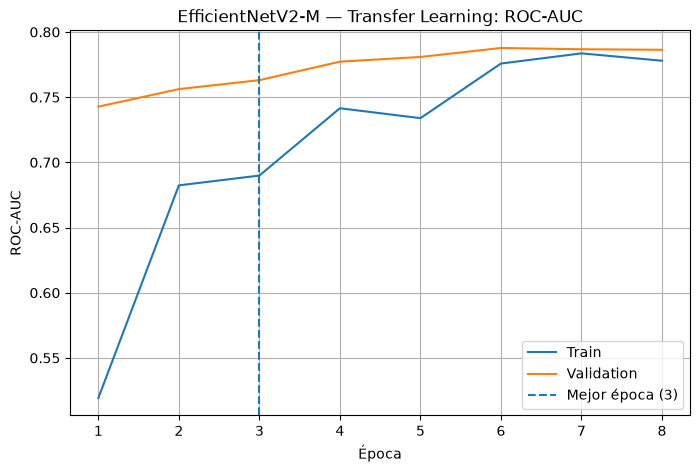

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_transfer,
    transfer_history_df["roc_auc"],
    label="Train"
)

plt.plot(
    epochs_transfer,
    transfer_history_df["val_roc_auc"],
    label="Validation"
)

plt.axvline(
    best_transfer_epoch,
    linestyle="--",
    label=f"Mejor época ({best_transfer_epoch})"
)

plt.xlabel("Época")
plt.ylabel("ROC-AUC")
plt.title(
    "EfficientNetV2-M — Transfer Learning: ROC-AUC"
)
plt.legend()
plt.grid(True)
plt.show()


### 20.3. Curva de precisión-exhaustividad (PR-AUC) — Transfer Learning

Evolución del área bajo la curva Precision-Recall en Train y Validation durante Transfer Learning.


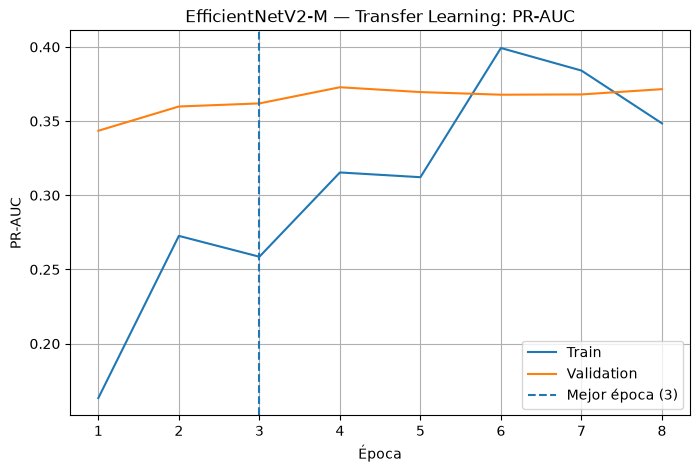

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_transfer,
    transfer_history_df["pr_auc"],
    label="Train"
)

plt.plot(
    epochs_transfer,
    transfer_history_df["val_pr_auc"],
    label="Validation"
)

plt.axvline(
    best_transfer_epoch,
    linestyle="--",
    label=f"Mejor época ({best_transfer_epoch})"
)

plt.xlabel("Época")
plt.ylabel("PR-AUC")
plt.title(
    "EfficientNetV2-M — Transfer Learning: PR-AUC"
)
plt.legend()
plt.grid(True)
plt.show()


### 20.4. Curva de pérdida (Loss) — Fine-Tuning

Evolución de la función de pérdida en Train y Validation durante el Fine-Tuning.


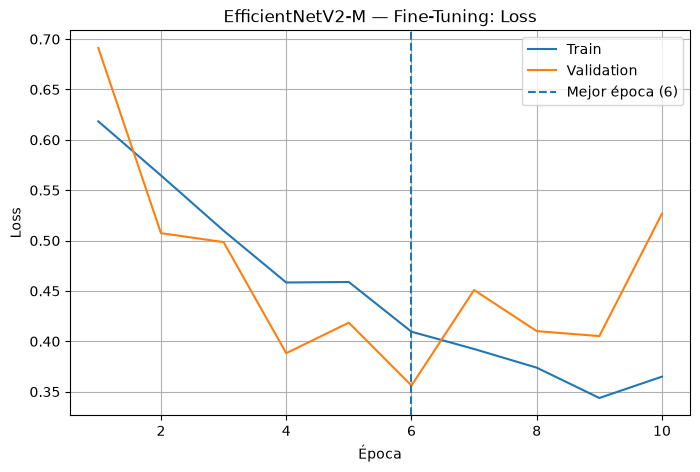

In [22]:
epochs_finetune = (
    finetune_history_df["epoch"] + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_finetune,
    finetune_history_df["loss"],
    label="Train"
)

plt.plot(
    epochs_finetune,
    finetune_history_df["val_loss"],
    label="Validation"
)

plt.axvline(
    best_finetune_epoch,
    linestyle="--",
    label=f"Mejor época ({best_finetune_epoch})"
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title(
    "EfficientNetV2-M — Fine-Tuning: Loss"
)
plt.legend()
plt.grid(True)
plt.show()


### 20.5. Curva de discriminación (ROC-AUC) — Fine-Tuning

Evolución de ROC-AUC en Train y Validation durante el Fine-Tuning.


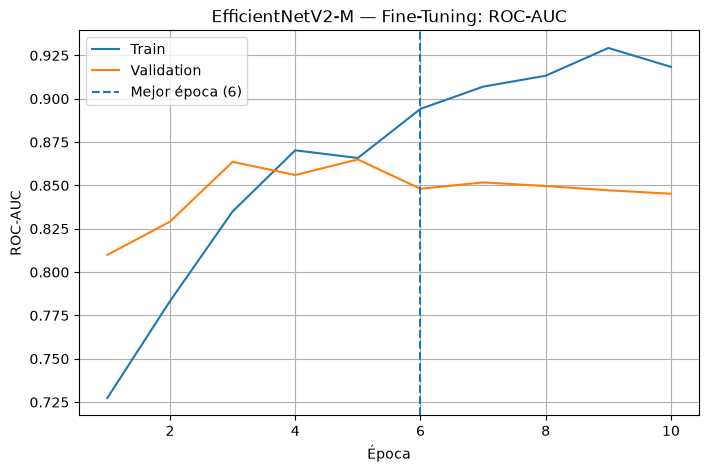

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_finetune,
    finetune_history_df["roc_auc"],
    label="Train"
)

plt.plot(
    epochs_finetune,
    finetune_history_df["val_roc_auc"],
    label="Validation"
)

plt.axvline(
    best_finetune_epoch,
    linestyle="--",
    label=f"Mejor época ({best_finetune_epoch})"
)

plt.xlabel("Época")
plt.ylabel("ROC-AUC")
plt.title(
    "EfficientNetV2-M — Fine-Tuning: ROC-AUC"
)
plt.legend()
plt.grid(True)
plt.show()


### 20.6. Curva de precisión-exhaustividad (PR-AUC) — Fine-Tuning

Evolución del área bajo la curva Precision-Recall en Train y Validation durante Fine-Tuning.


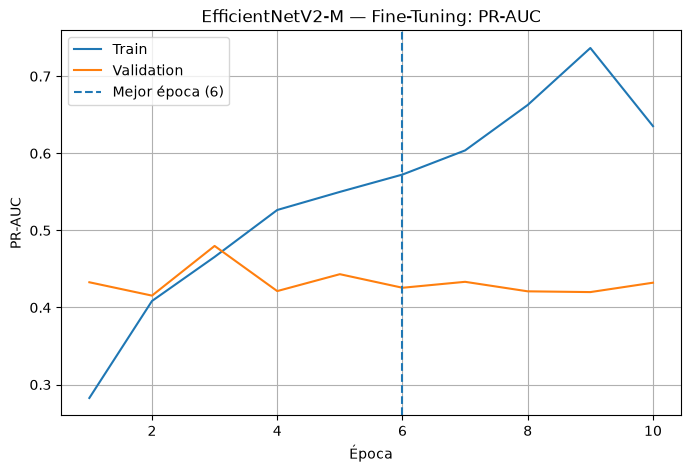

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_finetune,
    finetune_history_df["pr_auc"],
    label="Train"
)

plt.plot(
    epochs_finetune,
    finetune_history_df["val_pr_auc"],
    label="Validation"
)

plt.axvline(
    best_finetune_epoch,
    linestyle="--",
    label=f"Mejor época ({best_finetune_epoch})"
)

plt.xlabel("Época")
plt.ylabel("PR-AUC")
plt.title(
    "EfficientNetV2-M — Fine-Tuning: PR-AUC"
)
plt.legend()
plt.grid(True)
plt.show()


## 21. Comparación entre Transfer Learning y Fine-Tuning

Comparación de los mejores checkpoints de ambas fases utilizando como
criterio de selección la mínima `val_loss`.

Las métricas calculadas con umbral 0.5 se consideran provisionales y
no corresponden todavía al umbral operativo final del modelo.


In [25]:
phase_comparison = pd.DataFrame(
    {
        "Transfer Learning": {
            "best_epoch": best_transfer_epoch,
            "val_loss": best_transfer["val_loss"],
            "val_accuracy": best_transfer["val_accuracy"],
            "val_roc_auc": best_transfer["val_roc_auc"],
            "val_pr_auc": best_transfer["val_pr_auc"],
            "val_precision": best_transfer["val_precision"],
            "val_recall": best_transfer["val_recall"]
        },

        "Fine-Tuning": {
            "best_epoch": best_finetune_epoch,
            "val_loss": best_finetune["val_loss"],
            "val_accuracy": best_finetune["val_accuracy"],
            "val_roc_auc": best_finetune["val_roc_auc"],
            "val_pr_auc": best_finetune["val_pr_auc"],
            "val_precision": best_finetune["val_precision"],
            "val_recall": best_finetune["val_recall"]
        }
    }
)

display(
    phase_comparison.round(6)
)


,Transfer Learning,Fine-Tuning
best_epoch,3.000000,6.000000
val_loss,0.520004,0.356080
val_accuracy,0.801980,0.836634
val_roc_auc,0.763069,0.848042
val_pr_auc,0.361927,0.425610
val_precision,0.290323,0.421053
val_recall,0.333333,0.592593
